In [ ]:
##### Importance sampling from monte carlo sampling

Running 60 jobs across 10 threads...
  [1/60]  d=3  p=1.00e-05  LER=5.000e-06
  [2/60]  d=3  p=1.13e-04  LER=2.250e-04
  [3/60]  d=3  p=1.62e-05  LER=1.500e-05
  [4/60]  d=3  p=2.64e-05  LER=3.000e-05
  [5/60]  d=3  p=4.28e-05  LER=6.500e-05
  [6/60]  d=3  p=6.95e-05  LER=1.750e-04
  [7/60]  d=3  p=1.83e-04  LER=4.550e-04
  [8/60]  d=3  p=7.85e-04  LER=5.100e-03
  [9/60]  d=3  p=3.36e-03  LER=6.597e-02
  [10/60]  d=3  p=2.07e-03  LER=2.942e-02
  [11/60]  d=3  p=2.98e-04  LER=1.030e-03
  [12/60]  d=3  p=1.27e-03  LER=1.221e-02
  [13/60]  d=3  p=4.83e-04  LER=2.235e-03
  [14/60]  d=3  p=1.44e-02  LER=3.910e-01
  [15/60]  d=3  p=5.46e-03  LER=1.388e-01
  [16/60]  d=3  p=8.86e-03  LER=2.574e-01
  [17/60]  d=3  p=6.16e-02  LER=5.032e-01
  [18/60]  d=3  p=2.34e-02  LER=4.747e-01
  [19/60]  d=5  p=1.00e-05  LER=0.000e+00
  [20/60]  d=5  p=2.64e-05  LER=5.000e-06
  [21/60]  d=3  p=3.79e-02  LER=4.985e-01
  [22/60]  d=5  p=4.28e-05  LER=0.000e+00
  [23/60]  d=3  p=1.00e-01  LER=5.012e-01
  [24/

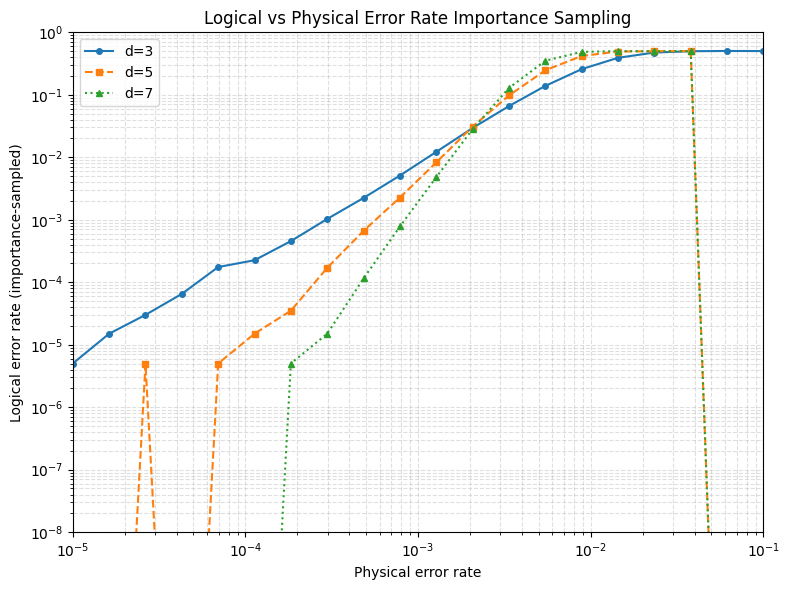

In [ ]:
##Logical vs Phsyical Error Rate
import numpy as np
import stim
import pymatching
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed

###generate circuit surface code: rotated memory x
def gen_circuit(d, p):
    return stim.Circuit.generated(
        code_task="surface_code:rotated_memory_x",
        distance=d,
        rounds=d,
        after_clifford_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
        before_round_data_depolarization=p,
    )


def run_job(args):
    d, p, min_failures_base, max_shots, adaptive_scale = args

    bias = 3.0 ## importance bias
    p_bias = min(0.25, p * bias)

    circuit = gen_circuit(d, p_bias)
    dem = circuit.detector_error_model()
    decoder = pymatching.Matching.from_detector_error_model(dem) ## uses py matching for decoder
    sampler = circuit.compile_detector_sampler()

    n_sites = 2000 * d

    def log_weight(k, pb):
        return (
            k * np.log(p / pb)
            + (n_sites - k) * np.log((1 - p) / (1 - pb))
        )

    pth = 0.006
    scale = adaptive_scale + (1 - adaptive_scale) * min(1.0, pth / p)
    min_failures = max(10, int(min_failures_base * scale))

    shots = 50_000

    weighted_failures = 0.0
    weighted_total = 0.0
    total_shots = 0

    while True:
        dets, obs = sampler.sample(shots, separate_observables=True)
        preds = decoder.decode_batch(dets)

        failures = np.any(preds.astype(bool) != obs, axis=1)

        ###weighting 
        k_est = n_sites * p_bias
        w = np.exp(log_weight(k_est, p_bias))

        weighted_failures += np.sum(failures) * w
        weighted_total += shots * w
        total_shots += shots

        if weighted_failures >= min_failures or total_shots >= max_shots:
            break

        shots = min(shots * 2, max_shots - total_shots)
        if shots <= 0:
            break

    ##estimator(weighted)
    ler = weighted_failures / weighted_total if weighted_total > 0 else 0.0

    return d, p, ler

def run_sweep(
    distances=(3, 5, 7),
    n_grid=20,
    min_failures=100,
    max_shots=2_00_000, ## larger than 1 million for sharpness
    adaptive_scale=0.5,
    max_workers=10,
):
    ps = np.logspace(-5, -1, n_grid) ## shows zig zags past 10e-5, included to show

    jobs = [
        (d, p, min_failures, max_shots, adaptive_scale)
        for d in distances
        for p in ps
    ]

    results = {d: [None] * n_grid for d in distances}
    p_to_idx = {round(p, 15): i for i, p in enumerate(ps)}

    total = len(jobs)
    print(f"Running {total} jobs across {max_workers} threads...")

    with ThreadPoolExecutor(max_workers=max_workers) as ex: ## used to make it easier on my computer or anyones for that matter
        futures = {ex.submit(run_job, job): job for job in jobs}

        done = 0
        for fut in as_completed(futures):
            d, p, ler = fut.result()
            results[d][p_to_idx[round(p, 15)]] = ler
            done += 1
            print(f"  [{done}/{total}]  d={d}  p={p:.2e}  LER={ler:.3e}")

    return ps, results


def plot(ps, results):
    fig, ax = plt.subplots(figsize=(8, 6))
    styles = {3: ("-", "o"), 5: ("--", "s"), 7: (":", "^")}

    for d, ys in results.items():
        ls, mk = styles[d]
        ys = np.clip(np.array(ys, dtype=float), 1e-16, None)

        ax.loglog(ps, ys, linestyle=ls, marker=mk,
                  linewidth=1.5, markersize=4, label=f"d={d}")

    ax.set_xlim(1e-5, 1e-1)
    ax.set_ylim(1e-8, 1)
    ax.set_xlabel("Physical error rate")
    ax.set_ylabel("Logical error rate (importance-sampled)")
    ax.set_title("Logical vs Physical Error Rate Importance Sampling")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()


ps, results = run_sweep()
plot(ps, results)

In [ ]:

##failure spectrum vs failure weight
import numpy as np
import stim
import pymatching
import matplotlib.pyplot as plt
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.stats import linregress


def make_circuit(d, p):
    return stim.Circuit.generated(
        code_task="surface_code:rotated_memory_x",
        distance=d,
        rounds=d,
        after_clifford_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
        before_round_data_depolarization=p,
    )


def wilson_interval(successes_w, n_w, z=1.96):
    """Wilson interval adapted for weighted counts."""
    if n_w <= 0:
        return 0.0, 1.0
    p_hat = min(successes_w / n_w, 1.0)
    denom = 1 + z**2 / n_w
    centre = (p_hat + z**2 / (2 * n_w)) / denom
    half = z * np.sqrt(p_hat * (1 - p_hat) / n_w + z**2 / (4 * n_w**2)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)


def run_job(args):
    d, p, shots_total, bias = args

    p_bias = min(0.25, p * bias)

    circuit = make_circuit(d, p_bias)
    dem = circuit.detector_error_model()
    decoder = pymatching.Matching.from_detector_error_model(dem)
    dem_sampler = dem.compile_sampler()

    n_mechanisms = dem.num_errors

    # Accumulate per-weight-bin weighted failure/total counts
    fail_w  = defaultdict(float)
    total_w = defaultdict(float)

    remaining = shots_total
    batch = 50_000

    while remaining > 0:
        shots = min(batch, remaining)
        remaining -= shots

        dets, obs, faults = dem_sampler.sample(shots, return_errors=True)
        preds = decoder.decode_batch(dets)

        failures = np.any(preds.astype(bool) != obs, axis=1)
        k_vec = faults.sum(axis=1).astype(int)

        # Per-shot IS reweighting
        log_w = (
            k_vec * np.log(p / p_bias)
            + (n_mechanisms - k_vec) * np.log((1 - p) / (1 - p_bias))
        )
        log_w = np.clip(log_w, -500, 500)
        w = np.exp(log_w)

        for k, wi, fi in zip(k_vec, w, failures):
            total_w[k] += wi
            if fi:
                fail_w[k] += wi

    return d, fail_w, total_w


def compute_spectrum(fail_w, total_w, min_weight_total=10.0):
    ws, fw, lo, hi = [], [], [], []
    upper_bounds = []

    for w in sorted(total_w):
        tw = total_w[w]
        fw_val = fail_w.get(w, 0.0)
        if tw < min_weight_total:
            continue
        if fw_val == 0.0:
            _, u = wilson_interval(0, tw)
            upper_bounds.append((w, u))
        else:
            f = fw_val / tw
            l, u = wilson_interval(fw_val, tw)
            ws.append(w)
            fw.append(f)
            lo.append(f - l)
            hi.append(u - f)

    return np.array(ws), np.array(fw), np.array(lo), np.array(hi), upper_bounds


def fit_powerlaw(ws, fw):
    if len(ws) < 3:
        return None, None
    mask = np.array(fw) < 0.15
    wx = np.array(ws)[mask]
    fy = np.array(fw)[mask]
    if len(wx) < 2:
        wx, fy = np.array(ws)[:4], np.array(fw)[:4]
    if len(wx) < 2:
        return None, None
    slope, intercept, *_ = linregress(np.log10(wx), np.log10(fy))
    return slope, intercept


def run_sweep(
    distances=(3, 5, 7),
    p=0.006,
    shots_per_job=500_000,
    bias=5.0,
    max_workers=6,
):
    jobs = [(d, p, shots_per_job, bias) for d in distances]

    spectra = {}
    print(f"Running {len(jobs)} jobs (bias={bias}, shots={shots_per_job:,})...")

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(run_job, job): job for job in jobs}
        for fut in as_completed(futures):
            d, fail_w, total_w = fut.result()
            spectra[d] = compute_spectrum(fail_w, total_w)
            print(f"  d={d} done — {len(spectra[d][0])} bins with failures")

    return spectra


def plot_spectrum(spectra, p):
    styles = {
        3: ("o", "#5555cc"),
        5: ("s", "#229977"),
        7: ("^", "#cc4400"),
        #styles = {3: ("-", "o"), 5: ("--", "s"), 7: (":", "^")}
    }
    #styles={3: ("-", "r"), 5: ("--", "s"), 7: (":", "^")}

    fig, ax = plt.subplots(figsize=(6.5, 5.5))

    for d, (ws, fw, lo, hi, upper_bounds) in spectra.items():
        color = styles[d][1]
        marker = styles[d][0]

        # Power-law extrapolation line
        slope, intercept = fit_powerlaw(ws, fw)
        if slope is not None:
            w_min = max(ws.min() if len(ws) else 1, 1)
            w_extrap = np.logspace(np.log10(w_min) - 0.3, np.log10(max(ws.max() if len(ws) else 10, 10)) + 0.8, 300)
            f_extrap = np.clip(10**intercept * w_extrap**slope, 1e-16, 1)
            ax.plot(w_extrap, f_extrap, linestyle=":", color=color, linewidth=1.0, alpha=0.6, zorder=1)

        if len(ws):
            ax.errorbar(
                ws, fw,
                yerr=[lo, hi],
                marker=marker,
                color=color,
                markerfacecolor="none",
                markeredgecolor=color,
                markeredgewidth=1.2,
                markersize=5,
                linewidth=1.2,
                capsize=2,
                capthick=0.8,
                elinewidth=0.8,
                label=f"d={d}",
                linestyle="-",
                zorder=2,
            )

        for w_ub, u in upper_bounds:
            ax.annotate(
                "", xy=(w_ub, u * 0.55), xytext=(w_ub, u),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=0.9, mutation_scale=7),
                zorder=3,
            )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(0.8, 10**2.5)
    ax.set_ylim(1e-8, 1.2)
    ax.set_xlabel("fault weight $w$", fontsize=11)
    ax.set_ylabel("failure spectrum $f(w)$", fontsize=11)
    ax.set_title("Failure Spectrum vs Failure Weight Importance Sampling")
    ax.grid(True, which="major", linestyle="-", linewidth=0.4, alpha=0.5, color="gray")
    ax.grid(True, which="minor", linestyle="-", linewidth=0.2, alpha=0.3, color="gray")
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.legend(fontsize=10, framealpha=0.9, edgecolor="lightgray")
    fig.tight_layout()
    plt.show()


spectra = run_sweep(distances=[3, 5, 7], p=0.006, shots_per_job=500_000, bias=5.0)
plot_spectrum(spectra, p=0.006)

Running 3 jobs (bias=5.0, shots=500,000)...
  d=3 done — 8 bins with failures
  d=5 done — 23 bins with failures
